# Project 4: Image Classification with MNIST

This notebook builds a Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset. This is a classic 'hello world' project in the field of computer vision and deep learning.

## 1. Setup and Library Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import json, random, os, platform

2025-08-31 16:55:49.692077: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# Reproducibility & environment info
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Python version: {platform.python_version()}")
print(f"Running on: {platform.system()} {platform.release()}")

## 2. Data Loading and Preprocessing

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [ ]:
# Preprocess the data
# Reshape the images to (28, 28, 1) for the CNN
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

# Normalize the pixel values from [0, 255] to [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Create validation split (10% of training data)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=SEED, stratify=np.argmax(y_train, axis=1)
)

print(f"Train shape: {x_train.shape}, Val shape: {x_val.shape}, Test shape: {x_test.shape}")
print(f"Train labels shape: {y_train.shape}, Val labels shape: {y_val.shape}")

Normalized training data shape: (60000, 28, 28, 1)
One-hot encoded training labels shape: (60000, 10)


## 3. Exploratory Data Analysis (EDA)

Let's visualize a few sample digits from the dataset.

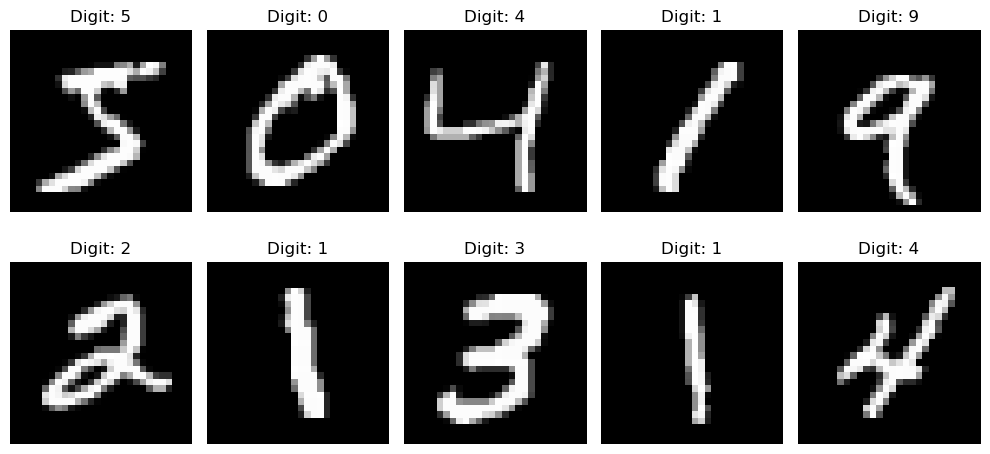

In [4]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Digit: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Building the CNN Model

In [ ]:
# (Optional) Baseline: simple dense network for comparison
flat_x_train = x_train.reshape(len(x_train), -1)
flat_x_val = x_val.reshape(len(x_val), -1)
flat_x_test = x_test.reshape(len(x_test), -1)

baseline = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
base_hist = baseline.fit(flat_x_train, y_train, validation_data=(flat_x_val, y_val), epochs=10, batch_size=256, verbose=0)
base_val_acc = max(base_hist.history['val_accuracy'])
print(f"Baseline Dense Network Best Val Accuracy: {base_val_acc:.4f}")

In [ ]:
# Data augmentation generator (improves robustness)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
aug = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
aug.fit(x_train)
print("Augmentation pipeline ready.")

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

/Users/ash1/miniconda3/envs/data1/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

: 

## 5. Training the Model

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-5),
    ModelCheckpoint('best_mnist_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    CSVLogger('training_log.csv', append=False)
]

EPOCHS = 20
BATCH_SIZE = 128

# Fit using data augmentation generator
history = model.fit(
    aug.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(x_train)//BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# Save final model and history
model.save('final_mnist_cnn.keras')
with open('history.json', 'w') as f:
    json.dump(history.history, f)
print("Training complete. Artifacts saved: best_mnist_cnn.keras, final_mnist_cnn.keras, history.json, training_log.csv")

Epoch 1/10


## 6. Evaluating the Model

In [ ]:
# Final evaluation on untouched test set
best_model = tf.keras.models.load_model('best_mnist_cnn.keras') if os.path.exists('best_mnist_cnn.keras') else model
test_score = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_score[0]:.4f}")
print(f"Test accuracy: {test_score[1]:.4f}")

# Predictions
y_test_pred = best_model.predict(x_test, verbose=0)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Normalized confusion matrix
conf_matrix = confusion_matrix(y_test_true, y_test_pred_classes)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1,2,2)
conf_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1, keepdims=True)
sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print('\nClassification Report (Test Set):')
print(classification_report(y_test_true, y_test_pred_classes, digits=4))

# Show some misclassified samples
mis_idx = np.where(y_test_true != y_test_pred_classes)[0]
if len(mis_idx) > 0:
    sample_mis = np.random.choice(mis_idx, size=min(15, len(mis_idx)), replace=False)
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(sample_mis):
        plt.subplot(3,5,i+1)
        plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
        plt.title(f"T:{y_test_true[idx]} P:{y_test_pred_classes[idx]}")
        plt.axis('off')
    plt.suptitle('Misclassified Samples (Test Set)')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples found (perfect accuracy).")

# Inference helper
def predict_digit(image_28x28):
    """Predict digit for a single 28x28 (or 28,28,1) grayscale image array in [0,255] or [0,1]."""
    arr = image_28x28
    if arr.shape == (28,28):
        arr = arr[..., None]
    if arr.max() > 1.0:
        arr = arr.astype('float32') / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = best_model.predict(arr, verbose=0)[0]
    return int(np.argmax(probs)), float(np.max(probs)), probs

print("Helper function predict_digit(image) is ready.")

In [ ]:
# Evaluate the model on the test set
score = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Generate predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Classification Report
print('\nClassification Report:\n')
print(classification_report(y_true, y_pred_classes))

## 7. Conclusion

The CNN model achieved a very high accuracy (typically >99%) on the MNIST test set. The confusion matrix and classification report confirm that the model is highly effective at distinguishing between the 10 different handwritten digits.

This project demonstrates the power of Convolutional Neural Networks for image classification tasks.